# 05 — Continuous Field Mapping & Interpolation
**Part 5 of 7** | GeoMetric Project

## Learning Objectives
- Distinguish continuous fields from discrete regional data
- Implement RBF and IDW interpolation
- Create isopleth/contour maps with proper uncertainty annotation

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from scipy.ndimage import gaussian_filter
from scripts.utils.config import PATHS, STYLE, INTERPOLATION
from scripts.utils.map_utils import reproject_gdf, save_figure, add_map_annotations, points_to_gdf

In [2]:
world = gpd.read_file(PATHS["processed"] / "master_world.gpkg")
temps = pd.read_csv(PATHS["processed"] / "temperature_stations.csv")
print(f"Stations: {len(temps)}")
print(f"Temp range: {temps['mean_temp_c'].min():.1f}°C to {temps['mean_temp_c'].max():.1f}°C")
temps.describe()

Stations: 98
Temp range: -10.0°C to 29.7°C


,lat,lon,mean_temp_c
count,98.000000,98.000000,98.000000
mean,27.720612,24.782245,16.101422
std,25.697749,71.781560,8.307250
min,-37.810000,-149.900000,-9.966210
25%,15.880000,-2.825000,10.848594
50%,33.885000,24.335000,15.660757
75%,45.325000,77.135000,23.555080
max,69.350000,174.770000,29.747471


   Saved: map_temperature_points.png  (300 DPI)


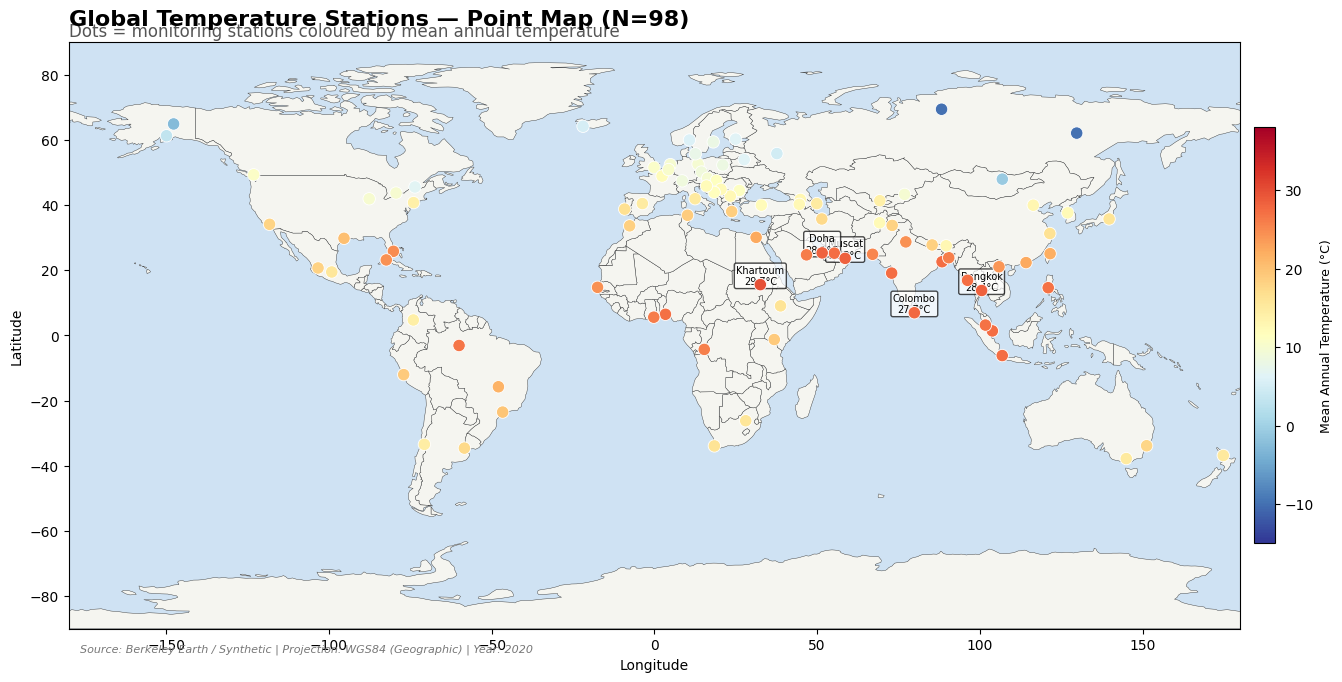

In [3]:
# ── Point map ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor(STYLE["ocean_color"])

if world.crs.to_epsg() != 4326:
    world_wgs = world.to_crs("EPSG:4326")
else:
    world_wgs = world
world_wgs.plot(ax=ax, color=STYLE["land_color"], linewidth=0.3, edgecolor=STYLE["boundary_color"])

sc = ax.scatter(temps["lon"], temps["lat"], c=temps["mean_temp_c"],
                cmap="RdYlBu_r", s=80, edgecolors="white", linewidths=0.6,
                zorder=5, vmin=-15, vmax=38)

for _, row in temps.nlargest(5, "mean_temp_c").iterrows():
    ax.annotate(f"{row['city']}\n{row['mean_temp_c']:.1f}°C",
                xy=(row["lon"], row["lat"]), fontsize=7, ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label("Mean Annual Temperature (°C)", fontsize=9)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
add_map_annotations(ax, title=f"Global Temperature Stations — Point Map (N={len(temps)})",
                    subtitle="Dots = monitoring stations coloured by mean annual temperature",
                    source="Berkeley Earth / Synthetic", projection_name="wgs84", year=2020)
save_figure(fig, PATHS["fig_part5"] / "map_temperature_points.png")
plt.show()

In [4]:
# ── RBF Interpolation ──────────────────────────────────────
lons = temps["lon"].values
lats = temps["lat"].values
vals = temps["mean_temp_c"].values

res  = INTERPOLATION["grid_resolution"]
lon_g = np.linspace(-180, 180, res * 2)
lat_g = np.linspace(-90, 90, res)
LON, LAT = np.meshgrid(lon_g, lat_g)

rbf  = RBFInterpolator(np.column_stack([lons, lats]), vals,
                       kernel="thin_plate_spline", smoothing=8)
TEMP = rbf(np.column_stack([LON.ravel(), LAT.ravel()])).reshape(LON.shape)
TEMP = gaussian_filter(TEMP, sigma=1.5)
print(f"Interpolation grid: {TEMP.shape} | Range: {TEMP.min():.1f} to {TEMP.max():.1f}°C")

Interpolation grid: (200, 400) | Range: -26.9 to 31.1°C


   Saved: map_temperature_contour.png  (300 DPI)


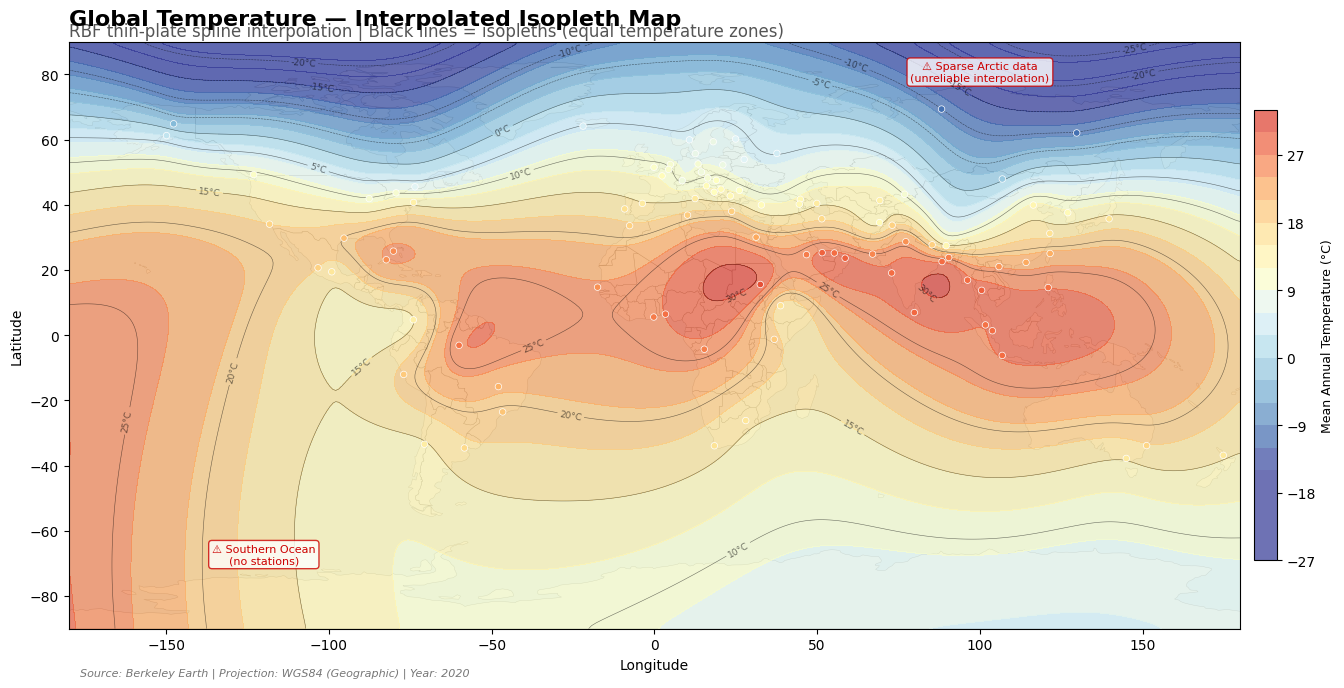

In [5]:
# ── Isopleth / contour map ─────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor(STYLE["ocean_color"])
world_wgs.plot(ax=ax, color=STYLE["land_color"], linewidth=0.3, edgecolor=STYLE["boundary_color"], alpha=0.5)

# Filled contours
cf = ax.contourf(LON, LAT, TEMP, levels=20, cmap="RdYlBu_r", alpha=0.7, vmin=-15, vmax=38)
# Isopleth lines
cs = ax.contour(LON, LAT, TEMP, levels=12, colors="black", linewidths=0.4, alpha=0.55)
ax.clabel(cs, inline=True, fontsize=6.5, fmt="%.0f°C", colors="black")

# Station points overlay
ax.scatter(lons, lats, c=vals, cmap="RdYlBu_r", s=22, edgecolors="white",
           linewidths=0.5, zorder=10, vmin=-15, vmax=38)

cbar = fig.colorbar(cf, ax=ax, shrink=0.65, pad=0.01)
cbar.set_label("Mean Annual Temperature (°C)", fontsize=9)

# Uncertainty annotations
for txt, xy in [
    ("⚠ Sparse Arctic data\n(unreliable interpolation)", (100, 78)),
    ("⚠ Southern Ocean\n(no stations)", (-120, -70)),
]:
    ax.annotate(txt, xy=xy, fontsize=8, color="#cc0000", ha="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cc0000", alpha=0.8))

ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
add_map_annotations(ax, title="Global Temperature — Interpolated Isopleth Map",
                    subtitle="RBF thin-plate spline interpolation | Black lines = isopleths (equal temperature zones)",
                    source="Berkeley Earth", projection_name="wgs84", year=2020, y_source=-0.08)
save_figure(fig, PATHS["fig_part5"] / "map_temperature_contour.png")
plt.show()

   Saved: rbf_vs_idw_comparison.png  (300 DPI)


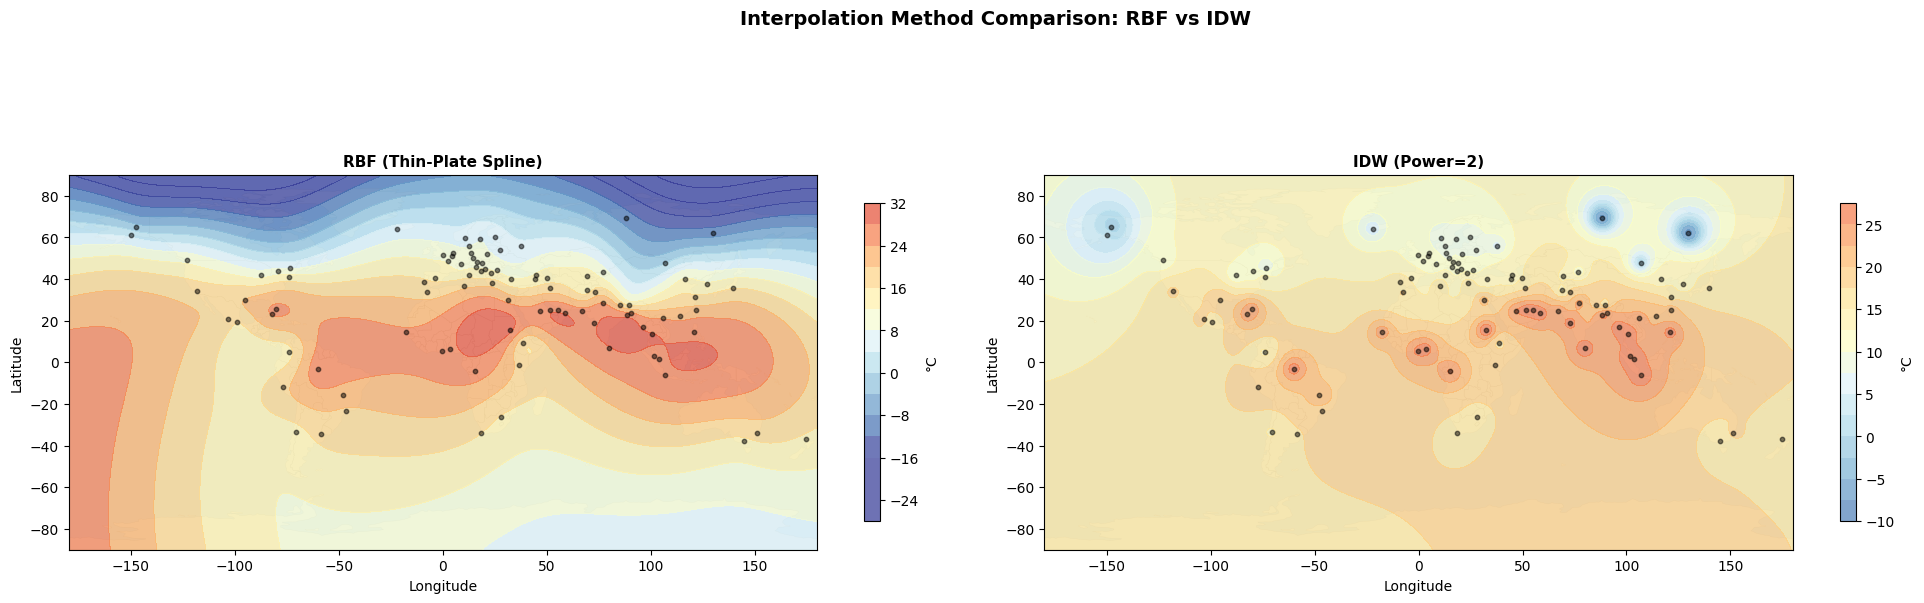

In [6]:
# ── IDW comparison ─────────────────────────────────────────
def idw_interpolate(lons, lats, vals, grid_lons, grid_lats, power=2):
    pts = np.column_stack([lons, lats])
    grid_pts = np.column_stack([grid_lons.ravel(), grid_lats.ravel()])
    dists = np.sqrt(((grid_pts[:,None,:] - pts[None,:,:])**2).sum(axis=2))
    dists = np.where(dists < 1e-10, 1e-10, dists)
    weights = 1.0 / dists**power
    result = (weights * vals).sum(axis=1) / weights.sum(axis=1)
    return result.reshape(grid_lons.shape)

TEMP_IDW = idw_interpolate(lons, lats, vals, LON, LAT, power=2)
TEMP_IDW = gaussian_filter(TEMP_IDW, sigma=1.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Interpolation Method Comparison: RBF vs IDW", fontsize=14, fontweight="bold")

for ax, data, title in [(ax1, TEMP, "RBF (Thin-Plate Spline)"), (ax2, TEMP_IDW, "IDW (Power=2)")]:
    ax.set_facecolor(STYLE["ocean_color"])
    world_wgs.plot(ax=ax, color=STYLE["land_color"], linewidth=0.2, edgecolor="#aaa", alpha=0.5)
    cf = ax.contourf(LON, LAT, data, levels=15, cmap="RdYlBu_r", alpha=0.7, vmin=-15, vmax=38)
    ax.scatter(lons, lats, c="black", s=10, zorder=10, alpha=0.5)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    fig.colorbar(cf, ax=ax, shrink=0.5, label="°C")

plt.tight_layout()
save_figure(fig, PATHS["fig_part5"] / "rbf_vs_idw_comparison.png")
plt.show()